<a href="https://colab.research.google.com/github/forSplinter/free_llm_2026_Intership/blob/dev/EDA_Preprocesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

#replace with the project folder e.g 'free/LLM_free_2O26/xxxxx'
FOLDERNAME = 'free_LLM_2026/technical_test'
assert FOLDERNAME is not None
PROJECT_DIR = f"/content/drive/MyDrive/{FOLDERNAME}"

import sys
sys.path.append(PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Prepare the datasets

In [3]:
%cd $PROJECT_DIR

from IPython.utils.text import string
import pandas as pd
import sqlite3
import os

def db_loader_csv(db_dir: str, table: str, csv_output:str) -> pd.DataFrame :
  assert os.path.exists(db_dir)

  conn = sqlite3.connect(db_dir)
  df = pd.read_sql_query(f"SELECT * FROM {table};", conn)
  conn.close()

  if csv_output:
    os.makedirs(os.path.dirname(csv_output), exist_ok=True)
    df.to_csv(csv_output, index=False)
    print(f'CSV convertion complete =>', {csv_output})

  return df

/content/drive/MyDrive/free_LLM_2026/technical_test


In [4]:
db_dir = 'db.sqlite'
csv_dir = 'data/csat_extract.csv'
table = 'csat_extract'
df = db_loader_csv(db_dir,table, csv_dir)

CSV convertion complete => {'data/csat_extract.csv'}


# Dataset basics

In [ ]:
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38303 entries, 0 to 38302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   contact_id        38303 non-null  int64  
 1   id_profil         38303 non-null  int64  
 2   id_conseiller     20000 non-null  float64
 3   date_contact      38303 non-null  object 
 4   csat              38303 non-null  int64  
 5   nps               38303 non-null  object 
 6   nom_departement   34966 non-null  object 
 7   nom_region        34966 non-null  object 
 8   du_societe_label  38303 non-null  object 
 9   canal             6927 non-null   object 
 10  offer_label       21149 non-null  object 
 11  commentaire       38302 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 3.5+ MB


In [ ]:
df.shape

(38303, 12)

In [ ]:
df.head()

,contact_id,id_profil,id_conseiller,date_contact,csat,nps,nom_departement,nom_region,du_societe_label,canal,offer_label,commentaire
0,49391456,20596135,135088.0,2025-10-19,3,6,\N,\N,\N,None,24: Freebox Pop | 39.99€,on donne toutes les infos à l’engagement et im...
1,49390924,15350417,135088.0,2025-10-19,4,7,\N,\N,\N,None,09: Freebox Révolution Light | 29.99€,"Saisi du Rio pas claire. Minuscule, pas Minusc..."
2,49390481,75269147,135088.0,2025-10-19,5,8,\N,\N,\N,None,28: Série Spéciale Freebox Pop S | 23.99€,Il manque la possibilité de choisir une date d...
3,49389164,24194380,135088.0,2025-10-19,5,9,\N,\N,\N,None,24: Freebox Pop | 39.99€,MERCI
4,49389166,48737310,135088.0,2025-10-19,4,8,\N,\N,\N,None,24: Freebox Pop | 39.99€,Il manque peut-être des précisions sur la pris...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38303 entries, 0 to 38302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   contact_id        38303 non-null  int64  
 1   id_profil         38303 non-null  int64  
 2   id_conseiller     20000 non-null  float64
 3   date_contact      38303 non-null  object 
 4   csat              38303 non-null  int64  
 5   nps               38303 non-null  object 
 6   nom_departement   34966 non-null  object 
 7   nom_region        34966 non-null  object 
 8   du_societe_label  38303 non-null  object 
 9   canal             6927 non-null   object 
 10  offer_label       21149 non-null  object 
 11  commentaire       38302 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 3.5+ MB


# EDA

Colonne qui ne nous seront sûrement pas utilise sont le contac_id, id_profile, nom_departement, nom_region, du_societe_label, ou encore le canal

## Missing Values

In [ ]:
df.replace(["\\N", "nan","NaN"], np.nan, inplace = True)
p_missing_value = df.isnull().sum()*100 / len(df)
p_missing_value.sort_values(ascending=False)

,0
nom_departement,87.940892
nom_region,87.940892
canal,81.915255
du_societe_label,48.962222
id_conseiller,47.784769
offer_label,44.785004
nps,9.599770
commentaire,0.002611
date_contact,0.000000
id_profil,0.000000


[OBS1]

In [ ]:
#we need to drop any column without comment
df = df.dropna(subset=['commentaire'])
df.shape

(38302, 12)

In [ ]:
#let's split or dataset by category
df.columns

Index(['contact_id', 'id_profil', 'id_conseiller', 'date_contact', 'csat',
       'nps', 'nom_departement', 'nom_region', 'du_societe_label', 'canal',
       'offer_label', 'commentaire'],
      dtype='object')

In [ ]:
#convert date_contact in datetime
df['date_contact'] = pd.to_datetime(df['date_contact'], format='%Y-%m-%d')

In [ ]:
#don't give any releavent insight need to be drop or fillna(-1)
df['id_conseiller'].value_counts()
df['id_conseiller'].fillna(-1)

,id_conseiller
0,135088.0
1,135088.0
2,135088.0
3,135088.0
4,135088.0
...,...
38298,-1.0
38299,-1.0
38300,-1.0
38301,-1.0


[OBS2] Une stratégie que l’on pourrait envisager, mais qui n’est pas pertinente ici compte tenu de la taille du dataset et du pourcentage élevé de valeurs manquantes, serait de remplir les valeurs manquantes avec le mode (valeur la plus fréquente), la médiane ou la moyenne pour les colonnes numériques. Cela introduirait en effet un biais important. La meilleure approche reste de conserver ces colonnes, car elles apportent des insights précis selon le besoin métier. Il convient donc de garder les catégories les plus prédominantes et de regrouper le reste sous la catégorie "Others".

* df.nps = NaN les NaN seront remplacé par les valeurs les plus fréquentes (9% de valeurs manquante)

In [ ]:
for col in ['nom_departement', 'nom_region', 'canal', 'du_societe_label', 'offer_label']:
  df[col] = df[col].fillna('unknown')

In [ ]:
for col in ['nom_departement', 'nom_region', 'offer_label', 'du_societe_label', 'canal']:
  counts = df[col].value_counts()
  _ = counts[counts < 50].index
  df[col] = df[col].replace(_, 'Other')

In [ ]:
df['nps'] = df['nps'].fillna(df['nps'].mode()[0])
df['nps'].value_counts()

,count
nps,
10,18790
9,6284
0,3447
8,2627
7,1635
5,1457
6,1182
1,764
2,739


In [ ]:
#drop column
df = df.drop(columns=['contact_id', 'id_profil', 'id_conseiller'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38302 entries, 0 to 38302
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_contact      38302 non-null  datetime64[ns]
 1   csat              38302 non-null  int64         
 2   nps               38302 non-null  object        
 3   nom_departement   38302 non-null  object        
 4   nom_region        38302 non-null  object        
 5   du_societe_label  38302 non-null  object        
 6   canal             38302 non-null  object        
 7   offer_label       38302 non-null  object        
 8   commentaire       38302 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 2.9+ MB


## Feature distribution

In [ ]:
for col in ['nom_departement', 'nom_region', 'canal',
                 'du_societe_label', 'offer_label', 'nps', 'commentaire']:
                 df[col] = df[col].astype('category')

In [ ]:
#devide or data set for exploration
df_nums = df.select_dtypes(include=[np.int64, np.float64])
df_cat = df.select_dtypes(include=['category'])

In [ ]:
df_nums.describe().T

,count,mean,std,min,25%,50%,75%,max
csat,38302.0,4.12002,1.485043,1.0,4.0,5.0,5.0,5.0


[OBS3]

Text(0, 0.5, 'Count')

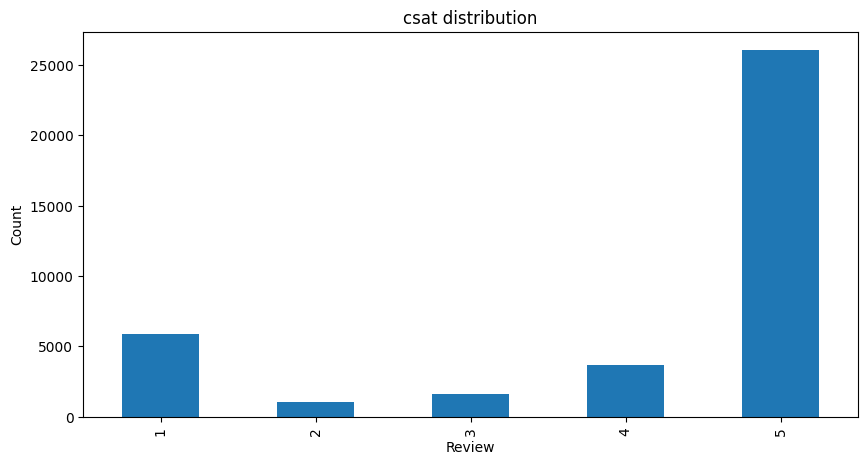

In [ ]:
#let see the repartition of this variable
ax = df_nums['csat'].value_counts().sort_index() \
    .plot(kind='bar', title='csat distribution',
          figsize=(10, 5),)
ax.set_xlabel('Review')
ax.set_ylabel('Count')

* La distribution est left-skewed, avec une concentration sur les score élevés
* la majorité des valeurs sont situé au niveau de 5 globalement les gens on l'air satisfait

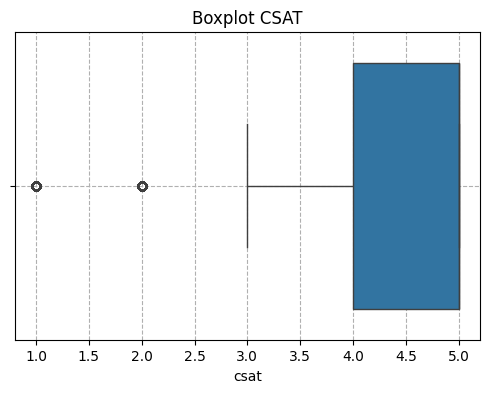

In [ ]:
#Outliers for csat
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['csat'])
plt.title('Boxplot CSAT')
plt.grid(True, linestyle='--')

Text(0, 0.5, 'Count')

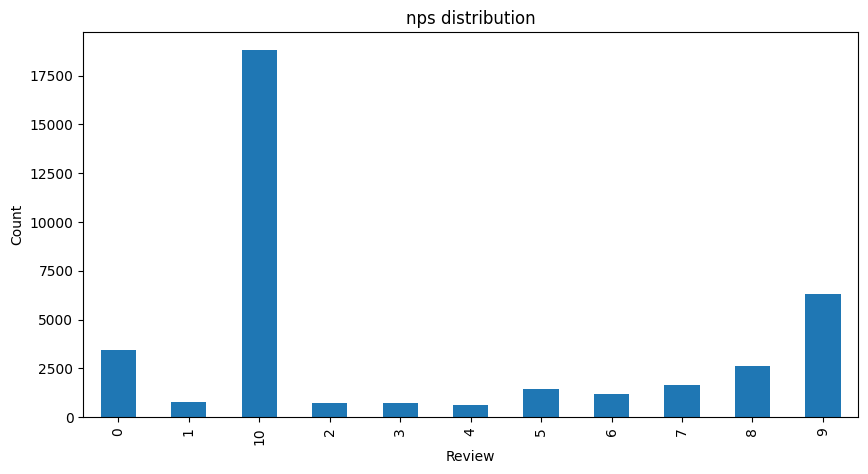

In [ ]:
#let see the repartition of this variable
ax = df_cat['nps'].value_counts().sort_index() \
    .plot(kind='bar', title='nps distribution',
          figsize=(10, 5),)
ax.set_xlabel('Review')
ax.set_ylabel('Count')

Ce graph n'est pas assez parlant pour une analyse de nps

In [ ]:
def nps_segment(score):
  if score <= 6:
    return 'Detractor'
  elif score <= 8:
    return 'Passif'
  else:
    return 'Promoter'


df['nps_segment'] = df['nps'].astype(float).apply(nps_segment)
df['nps_segment'].value_counts()

,count
nps_segment,
Promoter,25074
Detractor,8966
Passif,4262


Text(0, 0.5, 'Count')

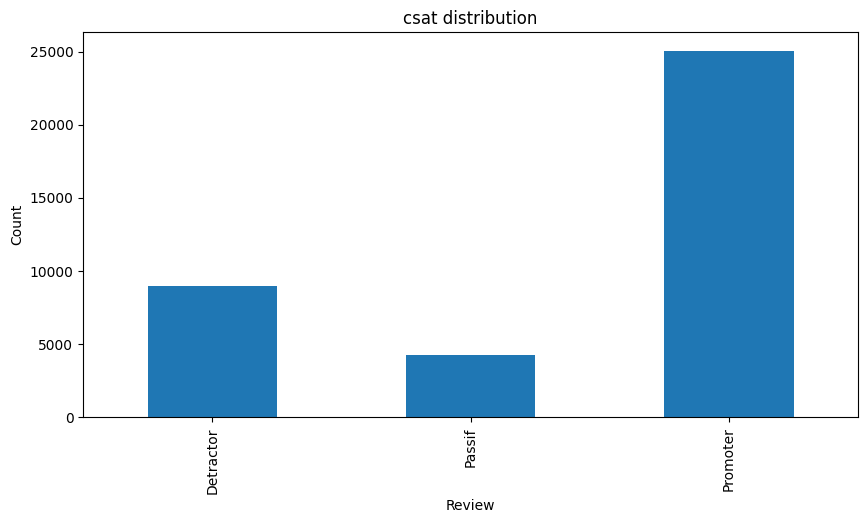

In [ ]:
#let see the repartition of this variable
ax = df['nps_segment'].value_counts().sort_index() \
    .plot(kind='bar', title='csat distribution',
          figsize=(10, 5),)
ax.set_xlabel('Review')
ax.set_ylabel('Count')

voyons voir si nps_segmen et CSAT sont croisez et correspondant mieux au niveau de satisfaction

In [ ]:
df.groupby('nps_segment')['csat'].describe()

,count,mean,std,min,25%,50%,75%,max
nps_segment,,,,,,,,
Detractor,8966.0,2.248494,1.570871,1.0,1.0,1.0,4.0,5.0
Passif,4262.0,4.349132,0.929641,1.0,4.0,5.0,5.0,5.0
Promoter,25074.0,4.750299,0.825201,1.0,5.0,5.0,5.0,5.0


* Les détracteurs sont principalement insatisfaits, mais une minorité a quand même donné des CSAT plus élevés.

* Les passifs sont dans leur globalité satisfait mais pas assez pour donner une meilleur note

* La majorité des clients sont très satisfait ce qui resulte aun e note nps entre 9-10 pour la plus part, comme vue plus haut les 1.0 représente des outliers qui sont assez négligable


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38302 entries, 0 to 38302
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_contact      38302 non-null  datetime64[ns]
 1   csat              38302 non-null  int64         
 2   nps               38302 non-null  category      
 3   nom_departement   38302 non-null  category      
 4   nom_region        38302 non-null  category      
 5   du_societe_label  38302 non-null  category      
 6   canal             38302 non-null  category      
 7   offer_label       38302 non-null  category      
 8   commentaire       38302 non-null  category      
 9   nps_segment       38302 non-null  object        
dtypes: category(7), datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB


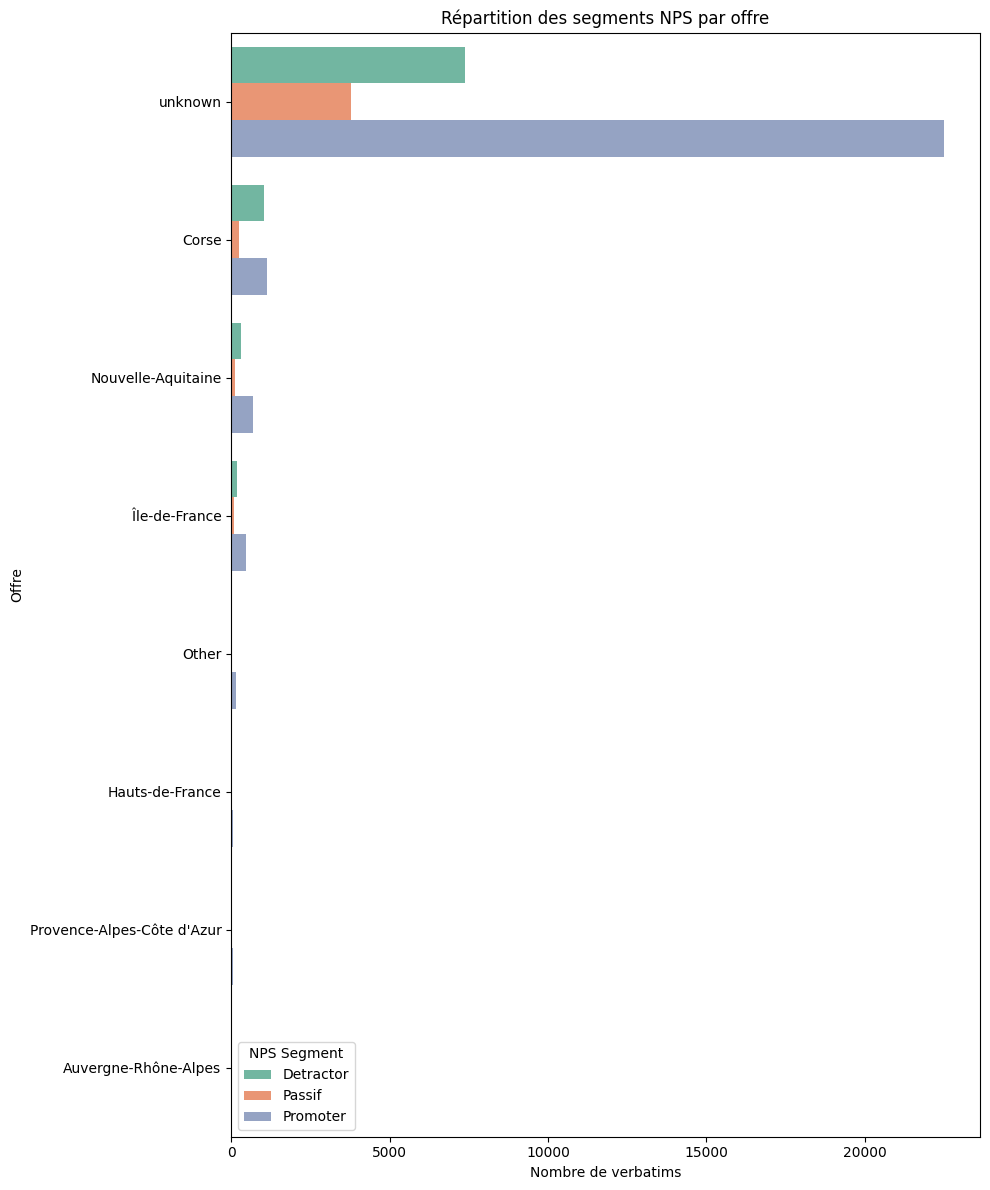

In [ ]:

plt.figure(figsize=(10,12))
sns.countplot(
    data=df,
    y='nom_region',       # axe Y = les offres
    hue='nps_segment',
    order=df['nom_region'].value_counts().index,     # tri par nombre de verbatims
    palette='Set2'
)

plt.title('Répartition des segments NPS par offre')
plt.xlabel('Nombre de verbatims')
plt.ylabel('Offre')
plt.legend(title='NPS Segment')
plt.tight_layout()
plt.show()


# EDA on commentaire


L’objectif de cette section est de comprendre la structure et les caractéristiques de la variable commentaire, afin d’identifier la meilleure manière de l'exploiter lors des étapes de modélisation.
Pour cette partie je resterais assez basic avec NLTK et Sapcy

Bien que la variable texte soit au cœur de cette analyse, nous conservons également les variables nom_departement et nom_region dans cette EDA (peut être les drop plus tard) Malgré un taux de valeurs manquantes élevé, elles présentent un intérêt métier important.

Elles peuvent facilement perment de segmenter géographiquement la satisfaction cliente et d'étudier avec le NLP les raisons expliquent pourquoi certaines règion affiches une satisfaction plus basse.


les offers lable peuvent peut être des enquêtes de satisfaction faite de manière indépendante sans être couplé a des offres

In [ ]:
!pip install spacy download fr_core_news_sm

In [ ]:
import nltk
import spacy
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
SEED = 42

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38302 entries, 0 to 38302
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_contact      38302 non-null  datetime64[ns]
 1   csat              38302 non-null  int64         
 2   nps               38302 non-null  category      
 3   nom_departement   38302 non-null  category      
 4   nom_region        38302 non-null  category      
 5   du_societe_label  38302 non-null  category      
 6   canal             38302 non-null  category      
 7   offer_label       38302 non-null  category      
 8   commentaire       38302 non-null  category      
 9   nps_segment       38302 non-null  object        
dtypes: category(7), datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB


In [ ]:
#we will work for this EDA on just a smal part of the dataset let's say 10%
df_sample = df.groupby('nps_segment', group_keys= False).apply(lambda x: x.sample(frac=0.10, random_state=SEED)).reset_index(drop=True)

/tmp/ipython-input-3958068656.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('nps_segment', group_keys= False).apply(lambda x: x.sample(frac=0.10, random_state=SEED)).reset_index(drop=True)


In [ ]:
#Ok nice the proportion are maintain
df_sample['nps_segment'].value_counts(normalize=True)

,proportion
nps_segment,
Promoter,0.654569
Detractor,0.234204
Passif,0.111227


In [ ]:
!pip install unidecode

In [ ]:
import re
import unidecode
def clean_text_and_norm(text:str) -> str:
  """
  """
  text = text.lower()
  text = unidecode.unidecode(text)
  text = re.sub(r"[^\w\s']", " ", text)
  text = re.sub(r"\s+", " ", text).strip()
  return text

In [ ]:
test = df_sample['commentaire'][10]

In [ ]:
clean_text_and_norm(test)

"en rebranchant ma fibre la fibre de mme jean leroy a ete deconnectee elle a demande aux techniciens de remettre tout comme avant ils n'ont pas repondu et sont partis laissant mme pierre thomas je n'ai recu aucune explication concernant notre panne et mme pierre martin n'a plus aucun service j'ai peur de la suite est ce que quand on depannera mme pierre thomas je garderai internet ou faudra t il encore vous appeler"

In [ ]:
nlp = spacy.load("fr_core_news_sm")
stop_fr = set(stopwords.words("french"))

## Preprocessing text

In [ ]:
class TextPreprocessor:
  def __init__(self, apply_lang_filter: bool =True, spell_check: bool =False, special_char_remove: bool =True, emoji_remove: bool =True, lemmatization: bool =True, stopword_remove: bool =True, apply_pos_tagging: bool =False, ner: bool =False)-> None:

    """

    """

    self.apply_pos_tagging = apply_lang_filter
    self.apply_lang_filter = apply_lang_filter
    self.spell_check=spell_check
    self.special_char_remove=special_char_remove
    self.emoji_remove = emoji_remove
    self.stopword_remove = stopword_remove
    self.lemmatization=lemmatization
    self.apply_pos_tagging=apply_pos_tagging
    self.ner = ner

  def clean_text(self, text: str) -> str:
    if not isinstance(text, str):
      return ""
    text = text.lower()
    text = unidecode.unidecode(text)
    if self.special_char_remove:
      text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

  def remove_stopwords(self, text: str) -> str:
    tokens = [w for w in text.split() if w not in stop_fr]
    return " ".join(tokens)

  def lemmatize_text(self, text: str) -> str:
    doc = nlp(text)
    lemmas = [tok.lemma_ for tok in doc if tok.lemma_ not in stop_fr]
    return " ".join(lemmas)

  def pos_taggin(self, text: str):
    doc = nlp(text)
    return [(tok.text, tok.pos_) for tok in doc]

  def extract_entities(self, text: str):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

  def preprocess(self, text: str) -> dict:
    if not text or not isinstance(text, str):
        return {"clean_text": None, "pos_tags": None, "entities": None}

    text = self.clean_text(text)

    if self.stopword_remove:
      text = self.remove_stopwords(text)

    if self.lemmatization:
      text = self.lemmatize_text(text)

    pos_tags = self.pos_taggin(text) if self.apply_pos_tagging else None
    entities = self.extract_entities(text) if self.ner else None

    return {
        "clean_text": text,
        "pos_tags": pos_tags,
        "entities": entities
    }


In [ ]:
preprocessor = TextPreprocessor(apply_lang_filter= True, spell_check=False, stopword_remove=True, ner=True, apply_pos_tagging=True)
preprocessor.preprocess(test)

{'clean_text': 'rebrancher fibre fibre mme jean leroy avoir ete deconnectee avoir demande technicien remettre tout comme avant avoir repondu parti laisser mme pierre thomas avoir recu aucun explication concerner pann mme pierre martin avoir plus aucun service avoir peur suite quand depannerer mme pierre thomas garderai internet falloir encore appeler',
 'pos_tags': [('rebrancher', 'VERB'),
  ('fibre', 'NOUN'),
  ('fibre', 'NOUN'),
  ('mme', 'NOUN'),
  ('jean', 'PROPN'),
  ('leroy', 'VERB'),
  ('avoir', 'VERB'),
  ('ete', 'DET'),
  ('deconnectee', 'VERB'),
  ('avoir', 'AUX'),
  ('demande', 'NOUN'),
  ('technicien', 'ADJ'),
  ('remettre', 'VERB'),
  ('tout', 'ADV'),
  ('comme', 'ADP'),
  ('avant', 'ADP'),
  ('avoir', 'AUX'),
  ('repondu', 'VERB'),
  ('parti', 'VERB'),
  ('laisser', 'VERB'),
  ('mme', 'NOUN'),
  ('pierre', 'PROPN'),
  ('thomas', 'PROPN'),
  ('avoir', 'AUX'),
  ('recu', 'PROPN'),
  ('aucun', 'DET'),
  ('explication', 'NOUN'),
  ('concerner', 'VERB'),
  ('pann', 'VERB'),
  

In [ ]:
#Before anything let clean or data_sample
df_sample['text_raw'] = df_sample['commentaire'].apply(preprocessor.clean_text)
df_sample['clean_commentaire'] = df_sample['text_raw'].copy()

In [ ]:
df_sample['clean_commentaire'] = df_sample['clean_commentaire'].apply(
    lambda x: preprocessor.remove_stopwords(x) if preprocessor.stopword_remove else x
)

In [ ]:
df_sample['clean_commentaire'] = df_sample['clean_commentaire'].apply(
    lambda x: preprocessor.lemmatize_text(x) if preprocessor.lemmatization else x
)

In [ ]:
# let create a tokens column form the statistiques
df_sample['tokens'] = df_sample['clean_commentaire'].apply(lambda x: x.split())

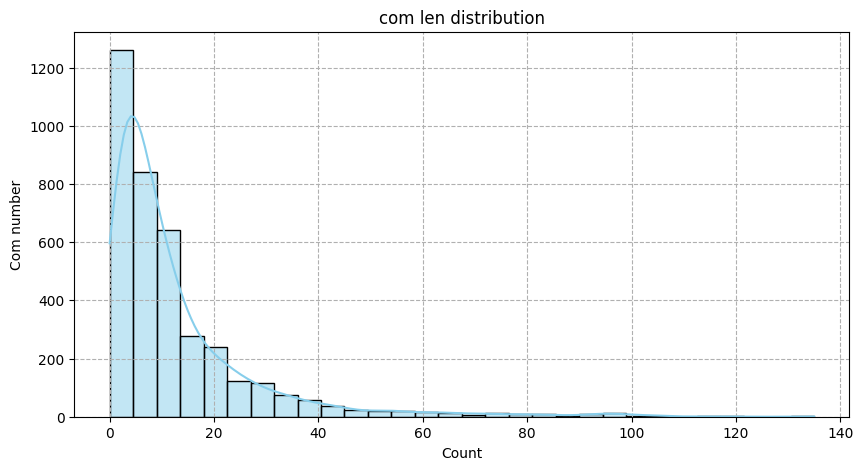

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_sample['tokens'].apply(len), bins=30, kde=True, color='skyblue')
plt.title('com len distribution')
plt.xlabel('Count')
plt.ylabel('Com number')
plt.grid(True, linestyle='--')

Ok les verbatims sont assez cours, il faudras pouvoir gérer les textes courts et long (ils apportent plus de contexte a la situation et propose plus d'entité)

/tmp/ipython-input-3068581214.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='nps_segment', y=df_sample['tokens'].apply(len), data=df_sample, palette="Set2", inner="quartile")


Text(0, 0.5, 'Nombre de mots')

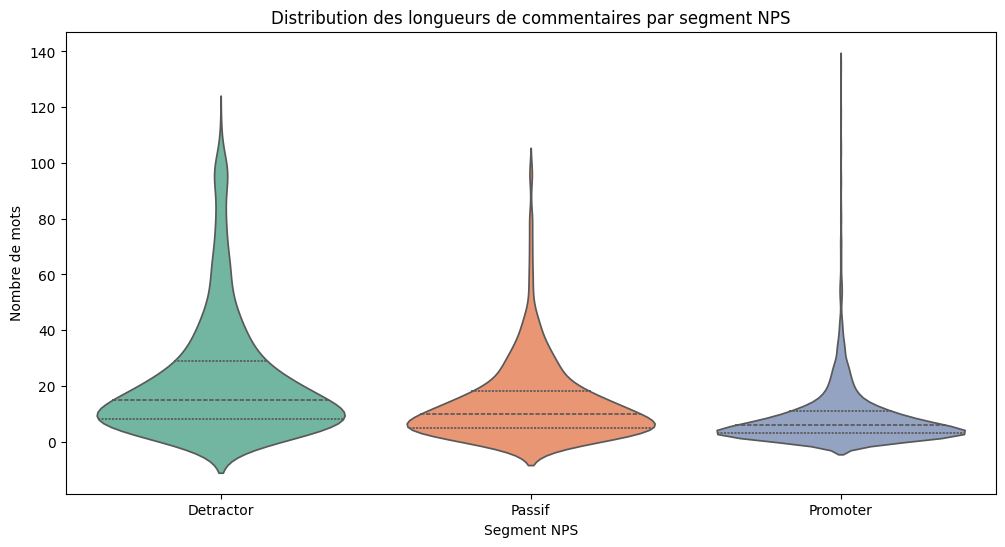

In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(x='nps_segment', y=df_sample['tokens'].apply(len), data=df_sample, palette="Set2", inner="quartile")
plt.title('Distribution des longueurs de commentaires par segment NPS')
plt.xlabel('Segment NPS')
plt.ylabel('Nombre de mots')

La Distribution est plus étalé vers les valeurs élées on a des commentaires plus long et plus détaillé quand les clients sont insatisfait. pour les Promoteurs la ditribution reste assez centré et concis

/tmp/ipython-input-2415276679.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  text = " ".join(df_sample[df['nps_segment'] == s]['clean_commentaire'])
/tmp/ipython-input-2415276679.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  text = " ".join(df_sample[df['nps_segment'] == s]['clean_commentaire'])
/tmp/ipython-input-2415276679.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  text = " ".join(df_sample[df['nps_segment'] == s]['clean_commentaire'])


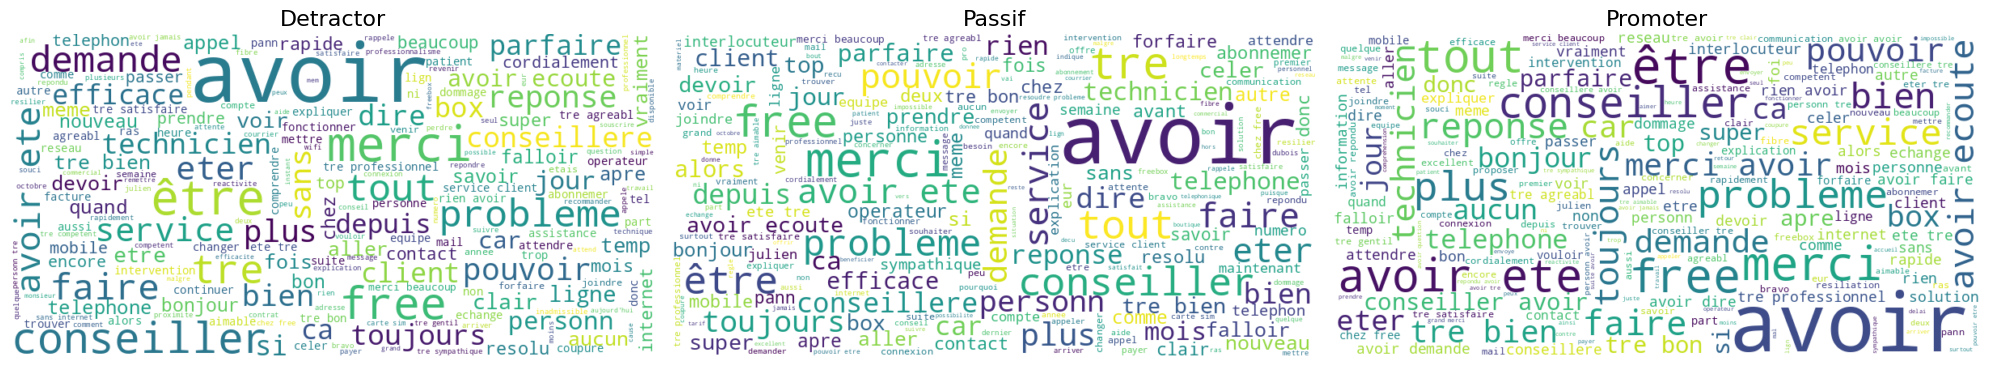

In [ ]:
## wordcloud
from wordcloud import WordCloud

plt.figure(figsize=(20, 10))
segments = df_sample['nps_segment'].unique()
for i, s in enumerate(segments , 1):
  text = " ".join(df_sample[df['nps_segment'] == s]['clean_commentaire'])
  wordcloud = WordCloud(
      width=800,
      height=400,
      max_font_size=100,
      background_color = 'white'
  ).generate(text)
  plt.subplot(1, len(segments), i)
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(f'{s}', fontsize=16)
plt.tight_layout()



Les mots avoir, problème, merci, conseiller on l'air de revenir assez souvent mais il faudrais plus de contexte surtout pour avoir donc construire un bi-gram semble le plus judicieux

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from typing import List, Tuple
def top_ngrams(corpus: List[str], ngram_range: Tuple[int,int]=(2,2), top_n: int=10) -> List[Tuple[str,int]]:
  """
  """
  vec = CountVectorizer(ngram_range=ngram_range, stop_words=list(stop_fr))
  X = vec.fit_transform(corpus)
  sum_words = X.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
  return words_freq[:top_n]

In [ ]:
corpus = df_sample['clean_commentaire'].tolist()
top_bigrams = top_ngrams(corpus, ngram_range=(3,3), top_n=15)
print(top_bigrams)

[('avoir ete tre', np.int64(81)), ('tre avoir ecoute', np.int64(53)), ('rien avoir dire', np.int64(51)), ('conseiller avoir ete', np.int64(30)), ('avoir ecoute avoir', np.int64(26)), ('avoir repondu avoir', np.int64(25)), ('avoir ecoute tre', np.int64(24)), ('grand merci avoir', np.int64(21)), ('tre bon accueil', np.int64(20)), ('personn tre agreabl', np.int64(18)), ('conseiller avoir ecoute', np.int64(17)), ('conseillere avoir ete', np.int64(17)), ('avoir tre bien', np.int64(17)), ('avoir ete resolu', np.int64(16)), ('avoir chaque fois', np.int64(15))]


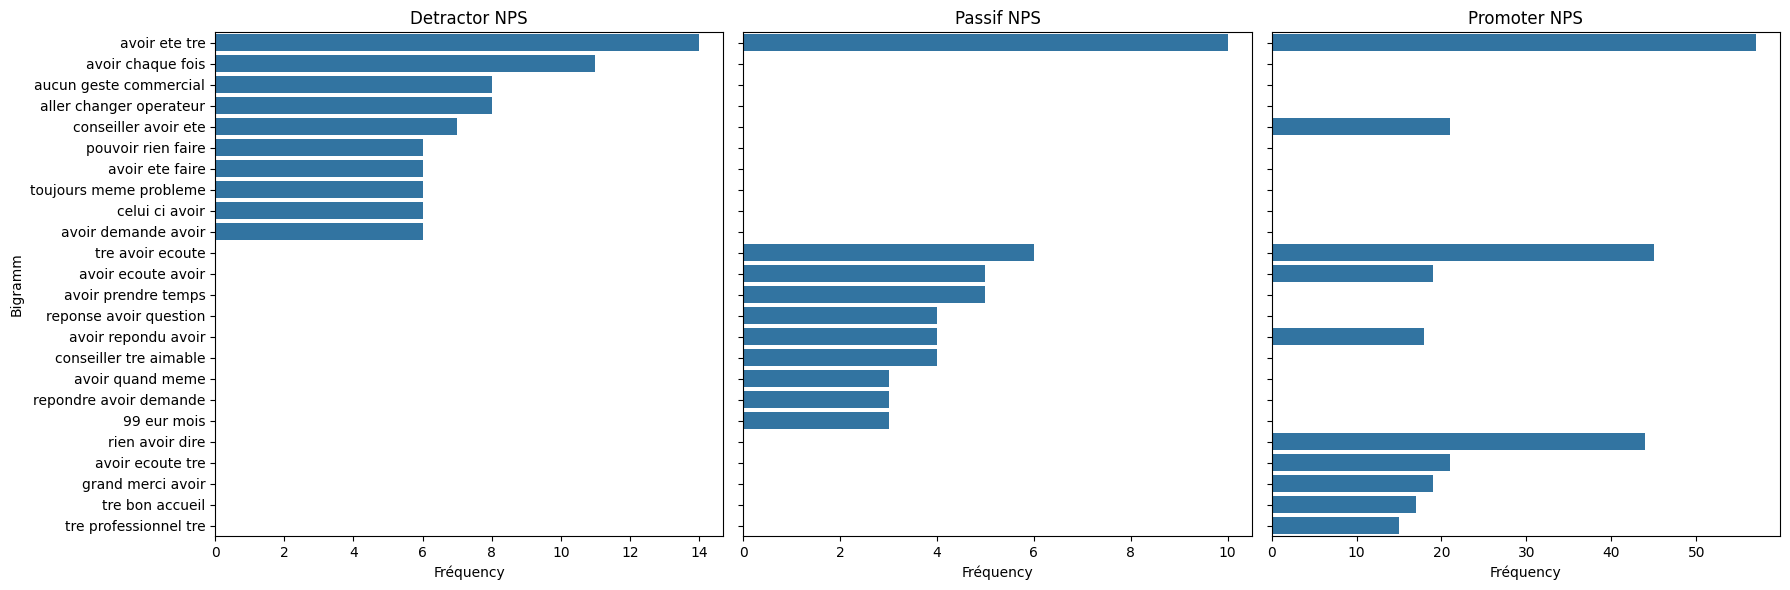

In [ ]:
segments = df_sample['nps_segment'].unique()
fig, axes = plt.subplots(1, len(segments), figsize=(18,6), sharey=True)

for i, s in enumerate(segments):
    corpus_seg = df_sample[df_sample['nps_segment'] == s]['clean_commentaire'].tolist()
    top_bigrams = top_ngrams(corpus_seg, ngram_range=(3,3), top_n=10)
    df_bigrams = pd.DataFrame(top_bigrams, columns=['bigram', 'count'])

    sns.barplot(data=df_bigrams, y='bigram', x='count', ax=axes[i])
    axes[i].set_title(f"{s} NPS")
    axes[i].set_xlabel("Fréquency")
    if i == 0:
        axes[i].set_ylabel("Bigramm")
    else:
        axes[i].set_ylabel("")

plt.tight_layout()